In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "EDA" else _HERE
_EDA  = _ROOT / "EDA"
for _p in (str(_ROOT), str(_EDA)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from config import DATA_DIR, PATHS, PARAMS
from analysis_helper import (
    calculate_diversity_ratio,
    calculate_bias_metrics,
    DataAnalysisPipeline,
)
from analysis_plot import (
    plot_knee,
    plot_batch_metric_violins,
    analyze_batch_statistics,
    plot_bias_correlations,
    plot_hc_variance_and_heatmap,
    plot_hc_pca_grid,
    check_batch_classification_power,
    check_bias_power_dist,
    plot_model_auc_grid,
    check_discrete_covariate_batch_effects,
    plot_covariate_auc_heatmap,
    plot_covariate_auc_violins,
)
from viz_style import apply_style
apply_style()

In [3]:
adata = sc.read_h5ad(PATHS["merged_qc"])
adata = adata[adata.obs["QC_Passed"] == True]

combined_metrics = [
    "log(Total Reads)", "Spliced Reads (%)", "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction", "RNA Degradation (3' Bias)", "Platelet Score",
    "GC Bias", "Gene Length Bias", "NG80", "NP80", "(NP80/NG80)",
    "Sample Volume (mL)", "Total Centrifugation Force (g)",
]

In [4]:
EXCLUDE_FROM_PHENOTYPE_ANALYSIS = ["Ibarra et al."]  # phenotype~batch confounded by design

In [5]:
bias_metrics = [
    "log(Total Reads)", "Spliced Reads (%)", "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction", "Platelet Score", "GC Bias", "Gene Length Bias",
    "RNA Degradation (3' Bias)", "NG80", "NP80", "(NP80/NG80)",
]

### Bias ~ Phenotype Relationship

In [6]:
obs = adata.obs.copy()
all_raw_res = []

for study in obs["Author"].unique():
    if study in EXCLUDE_FROM_PHENOTYPE_ANALYSIS:
        print(f"[Excluded] {study}: phenotype~batch confounded, skipping bias~phenotype analysis")
        continue
    try:
        df_meta = obs[obs["Author"] == study].copy()
        df_meta = df_meta[df_meta["Phenotype_Processed"].notna()]
        df_meta = df_meta[~df_meta["Phenotype_Processed"].isin(["Unknown", "nan"])]
        res_df = check_bias_power_dist(df_meta, bias_metrics, condition_col="Phenotype_Processed")
        if res_df is not None:
            res_df["Author"] = study
            all_raw_res.append(res_df)
    except Exception as e:
        print(f"Skipping {study}: {e}")

[Skip] Too few samples (N < 15).


[Skip] Too few samples (N < 15).
[Excluded] Ibarra et al.: phenotype~batch confounded, skipping bias~phenotype analysis


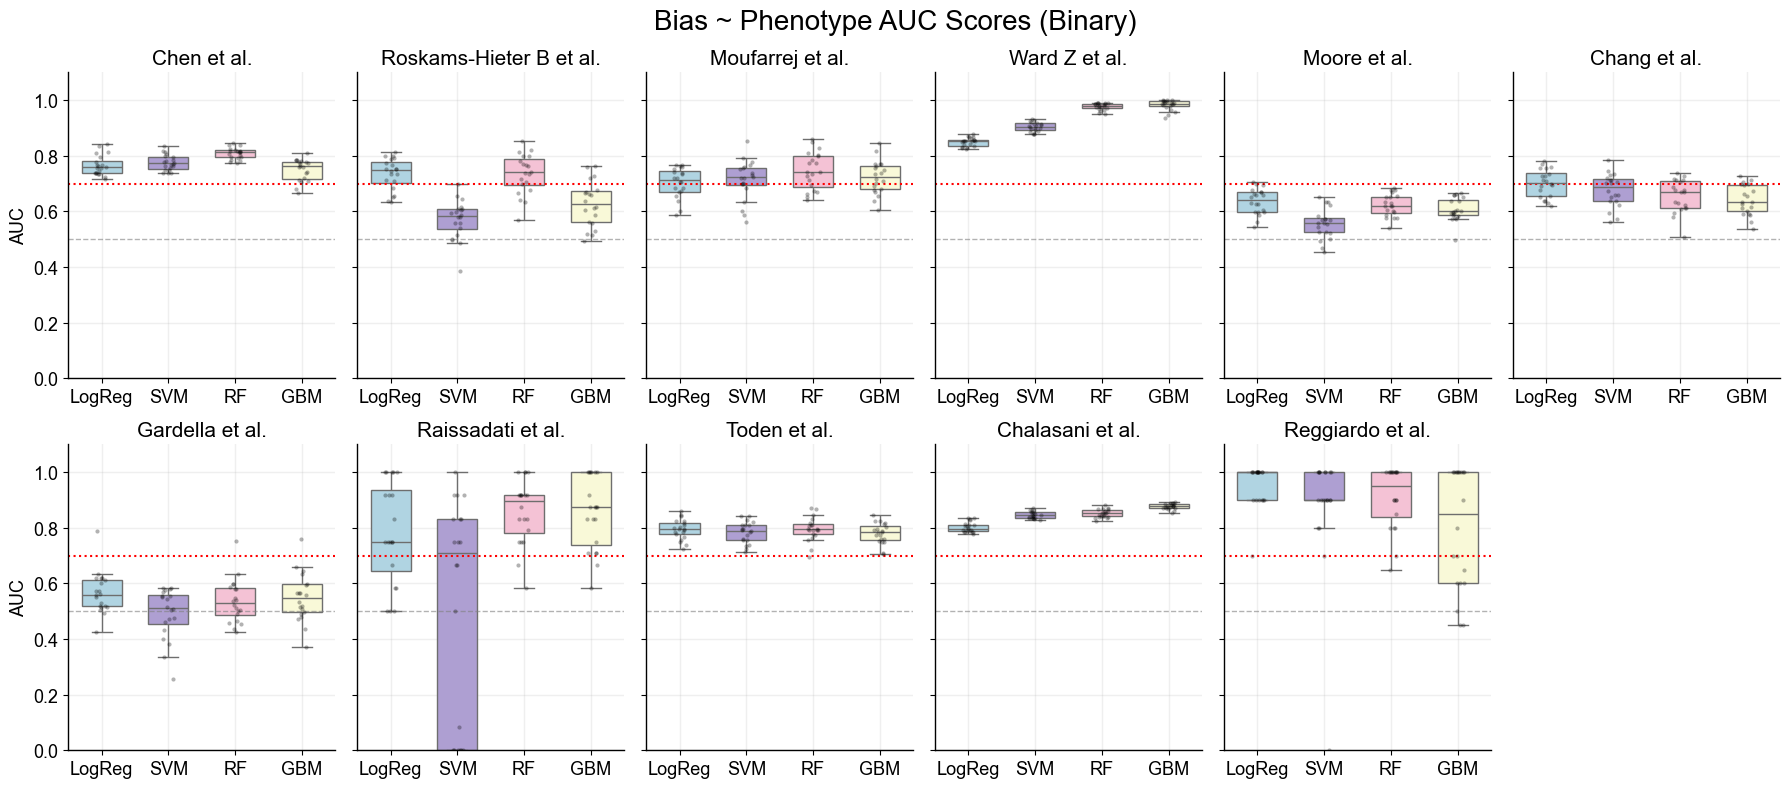

In [7]:
final_df = pd.concat(all_raw_res, axis=0).dropna()
plot_model_auc_grid(final_df, author_col="Author", n_cols=6, save_path=None)  # was "./Analysis_Results/bias_power_auc_grid.png"